# 🎬 IMDb Movies Data Analysis Project

### Author: Monojit Biswas
### Toolset: Python (Numpy, Pandas, Matplotlib, Seaborn)
### Date: October 2025

---

## Project Overview

This project explores the **IMDb Movies Dataset** to uncover patterns and insights related to
movie ratings, popularity, genres, budgets, and box office performance.  

The workflow follows a complete data analysis pipeline:
1. **Data Exploration, Cleaning, and Preparation** – understanding structure, fixing missing values, and standardizing columns.  
2. **Exploratory Data Analysis (EDA)** – discovering trends, correlations, and key factors influencing movie success.  
3. **Business Insights (Top-N Ranking Analysis)** – identifying top-performing movies, genres, directors, and countries based on revenue, ratings, and popularity.

## 1. Data Exploration, Cleaning and Preparation

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 120)
sns.set(style="whitegrid")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [82]:
df = pd.read_csv('movie_metadata.csv')
df.head(5)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,4834,Wes Studi,0.0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,48350,Jack Davenport,0.0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,11700,Stephanie Sigman,1.0,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0.0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8,143,NaN,0.0,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [83]:
print("shape:", df.shape)

df.info()

shape: (5043, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  504

In [84]:
# list of columns that should be int
int_cols = [
    'num_critic_for_reviews',
    'duration',
    'director_facebook_likes',
    'actor_3_facebook_likes',
    'actor_2_facebook_likes',
    'actor_1_facebook_likes',
    'facenumber_in_poster',
    'num_user_for_reviews',
    'title_year'
]

# convert to integer
for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').round().astype('Int64')

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   Int64  
 3   duration                   5028 non-null   Int64  
 4   director_facebook_likes    4939 non-null   Int64  
 5   actor_3_facebook_likes     5020 non-null   Int64  
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   Int64  
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [86]:
# missing values count and percentage by column
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).round(2)
pd.concat([missing, missing_pct], axis=1, keys=['missing_count','missing_%'])

,missing_count,missing_%
gross,884,17.53
budget,492,9.76
aspect_ratio,329,6.52
content_rating,303,6.01
plot_keywords,153,3.03
title_year,108,2.14
director_name,104,2.06
director_facebook_likes,104,2.06
num_critic_for_reviews,50,0.99
actor_3_name,23,0.46


In [87]:
# remove rows with missing gross or budget
df = df.dropna(subset=['gross', 'budget'])

In [88]:
# Fill object with unknown
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [89]:
df.isnull().sum().sum()

np.int64(101)

In [90]:
df[df.isnull().any(axis=1)].head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
99,Color,Peter Jackson,645,182,0,773,Adam Brown,5000,303001229.0,Adventure|Fantasy,Aidan Turner,The Hobbit: An Unexpected Journey,637246,9152,James Nesbitt,<NA>,dragon|dwarf|hobbit|orc|wizard,http://www.imdb.com/title/tt0903624/?ref_=fn_t...,1367,English,USA,PG-13,180000000.0,2012,972,7.9,2.35,166000
248,Color,Dave Green,181,112,13,799,Noel Fisher,5000,81638674.0,Action|Adventure|Comedy|Sci-Fi,Stephen Amell,Teenage Mutant Ninja Turtles: Out of the Shadows,17533,8306,Brad Garrett,<NA>,based on comic book|brother brother relationsh...,http://www.imdb.com/title/tt3949660/?ref_=fn_t...,115,English,USA,PG-13,135000000.0,2016,833,6.3,2.35,12000
624,Color,Will Finn,51,88,6,854,Oliver Platt,2000,8460990.0,Adventure|Animation|Family|Fantasy|Musical,Lea Michele,Legends of Oz: Dorothy's Return,5116,6946,Jim Belushi,1,jester|kansas|oz|princess|tornado,http://www.imdb.com/title/tt0884726/?ref_=fn_t...,54,English,USA,PG,70000000.0,2013,1000,5.6,NaN,5000
1782,Color,Jacques Perrin,100,81,63,<NA>,Philippe Labro,63,10762178.0,Documentary,Jacques Perrin,Winged Migration,10369,66,Unknown,0,arctic|bad weather|flight|migration|ocean,http://www.imdb.com/title/tt0301727/?ref_=fn_t...,153,English,France,G,160000000.0,2001,3,8.0,1.85,1000
1948,Unknown,Lasse Hallström,162,108,529,690,Henry Thomas,17000,80014842.0,Drama|Romance|War,Channing Tatum,Dear John,104356,19945,Scott Porter,<NA>,army|coin collector|love|surfboard|u.s. army,http://www.imdb.com/title/tt0989757/?ref_=fn_t...,186,English,USA,PG-13,25000000.0,2010,861,6.3,2.35,14000


In [91]:
print("duplicate rows:", df.duplicated().sum())

df[df.duplicated(keep=False)].head()

duplicate rows: 34


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
17,Color,Joss Whedon,703,173,0,19000,Robert Downey Jr.,26000,623279547.0,Action|Adventure|Sci-Fi,Chris Hemsworth,The Avengers,995415,87697,Scarlett Johansson,3,alien invasion|assassin|battle|iron man|soldier,http://www.imdb.com/title/tt0848228/?ref_=fn_t...,1722,English,USA,PG-13,220000000.0,2012,21000,8.1,1.85,123000
63,Color,David Yates,248,110,282,103,Alexander Skarsgård,11000,124051759.0,Action|Adventure|Drama|Romance,Christoph Waltz,The Legend of Tarzan,42372,21175,Casper Crump,2,africa|capture|jungle|male objectification|tarzan,http://www.imdb.com/title/tt0918940/?ref_=fn_t...,239,English,USA,PG-13,180000000.0,2016,10000,6.6,2.35,29000
100,Color,Rob Cohen,187,106,357,4000,Vin Diesel,23000,144512310.0,Action|Crime|Thriller,Paul Walker,The Fast and the Furious,272223,45327,Jordana Brewster,2,eighteen wheeler|illegal street racing|truck|t...,http://www.imdb.com/title/tt0232500/?ref_=fn_t...,988,English,USA,PG-13,38000000.0,2001,14000,6.7,2.35,14000
137,Color,David Yates,248,110,282,103,Alexander Skarsgård,11000,124051759.0,Action|Adventure|Drama|Romance,Christoph Waltz,The Legend of Tarzan,42372,21175,Casper Crump,2,africa|capture|jungle|male objectification|tarzan,http://www.imdb.com/title/tt0918940/?ref_=fn_t...,239,English,USA,PG-13,180000000.0,2016,10000,6.6,2.35,29000
145,Color,Joe Wright,256,111,456,394,Cara Delevingne,20000,34964818.0,Adventure|Family|Fantasy,Hugh Jackman,Pan,39956,21393,Nonso Anozie,4,1940s|child hero|fantasy world|orphan|referenc...,http://www.imdb.com/title/tt3332064/?ref_=fn_t...,186,English,USA,PG,150000000.0,2015,548,5.8,2.35,24000


In [92]:
df.duplicated(subset='movie_imdb_link').sum()

np.int64(101)

In [93]:
# show the rows that are duplicates
df[df.duplicated(subset='movie_imdb_link', keep=False)].sort_values('movie_imdb_link').head(10)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
3278,Color,Tobe Hooper,277,88,365,177,Edwin Neal,383,30859000.0,Horror|Thriller,Gunnar Hansen,The Texas Chain Saw Massacre,96410,1094,Marilyn Burns,0,cannibal|chainsaw|hitchhiker|independent film|...,http://www.imdb.com/title/tt0072271/?ref_=fn_t...,826,English,USA,R,83532.0,1974,371,7.5,1.85,0
4936,Color,Tobe Hooper,277,88,365,177,Edwin Neal,383,30859000.0,Horror|Thriller,Gunnar Hansen,The Texas Chain Saw Massacre,96411,1094,Marilyn Burns,0,cannibal|chainsaw|hitchhiker|independent film|...,http://www.imdb.com/title/tt0072271/?ref_=fn_t...,826,English,USA,R,83532.0,1974,371,7.5,1.85,0
2619,Color,John Carpenter,318,101,0,598,Donald Pleasence,2000,47000000.0,Horror|Thriller,Jamie Lee Curtis,Halloween,157857,4400,P.J. Soles,0,halloween|masked killer|michael myers|slasher|...,http://www.imdb.com/title/tt0077651/?ref_=fn_t...,1191,English,USA,R,300000.0,1978,742,7.9,2.35,12000
2492,Color,John Carpenter,318,101,0,598,Donald Pleasence,2000,47000000.0,Horror|Thriller,Jamie Lee Curtis,Halloween,157857,4400,P.J. Soles,0,halloween|masked killer|michael myers|slasher|...,http://www.imdb.com/title/tt0077651/?ref_=fn_t...,1191,English,USA,R,300000.0,1978,742,7.9,2.35,12000
4821,Color,John Carpenter,318,101,0,598,Donald Pleasence,2000,47000000.0,Horror|Thriller,Jamie Lee Curtis,Halloween,157863,4400,P.J. Soles,0,halloween|masked killer|michael myers|slasher|...,http://www.imdb.com/title/tt0077651/?ref_=fn_t...,1191,English,USA,R,300000.0,1978,742,7.9,2.35,12000
2420,Color,John Carpenter,212,89,0,606,Hal Holbrook,2000,21378000.0,Fantasy|Horror,Jamie Lee Curtis,The Fog,46492,4877,Janet Leigh,0,california|fog|leper|lighthouse|ship,http://www.imdb.com/title/tt0080749/?ref_=fn_t...,335,English,USA,R,1000000.0,1980,826,6.8,2.35,7000
4532,Color,John Carpenter,212,89,0,606,Hal Holbrook,2000,21378000.0,Fantasy|Horror,Jamie Lee Curtis,The Fog,46493,4878,Janet Leigh,0,california|fog|leper|lighthouse|ship,http://www.imdb.com/title/tt0080749/?ref_=fn_t...,335,English,USA,R,1000000.0,1980,826,6.8,2.35,7000
2193,Color,John Milius,166,129,468,183,Mako,919,37567440.0,Adventure|Fantasy,William Smith,Conan the Barbarian,113068,2024,Sandahl Bergman,0,actual animal killed|cult|evil sorcerer|gladia...,http://www.imdb.com/title/tt0082198/?ref_=fn_t...,337,English,USA,R,20000000.0,1982,691,6.9,2.35,0
390,Color,John Milius,166,129,468,183,Mako,919,37567440.0,Adventure|Fantasy,William Smith,Conan the Barbarian,113065,2024,Sandahl Bergman,0,actual animal killed|cult|evil sorcerer|gladia...,http://www.imdb.com/title/tt0082198/?ref_=fn_t...,337,English,USA,R,20000000.0,1982,691,6.9,2.35,0
3069,Color,Tobe Hooper,223,120,365,723,Zelda Rubinstein,887,76600000.0,Fantasy|Horror,Heather O'Rourke,Poltergeist,105448,3876,Craig T. Nelson,0,ghost|haunted|haunting|house|paranormal invest...,http://www.imdb.com/title/tt0084516/?ref_=fn_t...,321,English,USA,PG,10700000.0,1982,770,7.4,2.35,11000


In [94]:
# remove duplicates by imdb_link
df = df.drop_duplicates(subset='movie_imdb_link', keep='first')

In [95]:
# verify no duplicates remain
df.duplicated(subset='movie_imdb_link').sum()

np.int64(0)

In [96]:
print("shape:", df.shape)

shape: (3790, 28)


In [97]:
display(df.describe().T)
display(df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
num_critic_for_reviews,3789.0,160.7308,122.79857,1.0,71.0,131.0,218.0,813.0
duration,3789.0,109.80285,22.757211,34.0,95.0,105.0,120.0,330.0
director_facebook_likes,3790.0,786.612401,3038.048782,0.0,10.0,58.0,221.0,23000.0
actor_3_facebook_likes,3780.0,736.648413,1822.786699,0.0,182.0,424.0,683.0,23000.0
actor_1_facebook_likes,3787.0,7501.339319,15449.744426,0.0,716.0,1000.0,12000.0,640000.0
gross,3790.0,50192237.835884,68720235.463617,162.0,6534416.75,27177213.0,64950384.5,760505847.0
num_voted_users,3790.0,101411.51715,150672.136435,5.0,16656.5,49641.5,120693.5,1689764.0
cast_total_facebook_likes,3790.0,11112.22533,18911.5825,0.0,1798.0,3842.0,15831.25,656730.0
facenumber_in_poster,3784.0,1.385571,2.065185,0.0,0.0,1.0,2.0,43.0
num_user_for_reviews,3790.0,321.326649,402.75657,1.0,100.0,199.5,385.0,5060.0


,count,unique,top,freq
color,3790,3,Color,3660
director_name,3790,1753,Steven Spielberg,25
actor_2_name,3790,2289,Morgan Freeman,18
genres,3790,762,Drama,152
actor_1_name,3790,1510,Robert De Niro,42
movie_title,3790,3789,The Host,2
actor_3_name,3790,2689,Unknown,10
plot_keywords,3790,3760,Unknown,31
movie_imdb_link,3790,3790,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,1
language,3790,38,English,3607


In [98]:
# Inspect categorical values for inconsistencies
for c in df.select_dtypes(include='object').columns:
    print("COLUMN:", c)
    print((df[c].value_counts(dropna=False).head(10).reset_index()))
    print('-'*40)

COLUMN: color
              color  count
0             Color   3660
1   Black and White    128
2           Unknown      2
----------------------------------------
COLUMN: director_name
       director_name  count
0   Steven Spielberg     25
1        Woody Allen     19
2     Clint Eastwood     19
3    Martin Scorsese     16
4       Ridley Scott     16
5  Steven Soderbergh     15
6       Renny Harlin     15
7          Spike Lee     15
8         Tim Burton     14
9     Barry Levinson     13
----------------------------------------
COLUMN: actor_2_name
         actor_2_name  count
0      Morgan Freeman     18
1           Brad Pitt     13
2     Charlize Theron     13
3        James Franco     10
4        Meryl Streep     10
5         Scott Glenn      9
6        Adam Sandler      9
7        Bruce Willis      9
8        Will Ferrell      9
9  Jada Pinkett Smith      8
----------------------------------------
COLUMN: genres
                        genres  count
0                        Drama  

## 2. Exploratory Data Analysis (EDA)

### 2.1 Univariate Analysis

In [99]:
# asic Overview
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3790 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      3790 non-null   object 
 1   director_name              3790 non-null   object 
 2   num_critic_for_reviews     3789 non-null   Int64  
 3   duration                   3789 non-null   Int64  
 4   director_facebook_likes    3790 non-null   Int64  
 5   actor_3_facebook_likes     3780 non-null   Int64  
 6   actor_2_name               3790 non-null   object 
 7   actor_1_facebook_likes     3787 non-null   Int64  
 8   gross                      3790 non-null   float64
 9   genres                     3790 non-null   object 
 10  actor_1_name               3790 non-null   object 
 11  movie_title                3790 non-null   object 
 12  num_voted_users            3790 non-null   int64  
 13  cast_total_facebook_likes  3790 non-null   int64  
 1

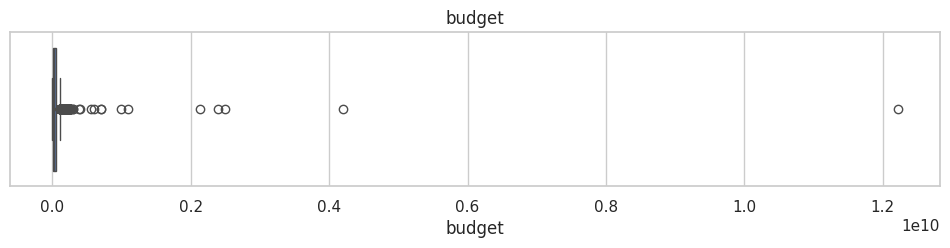

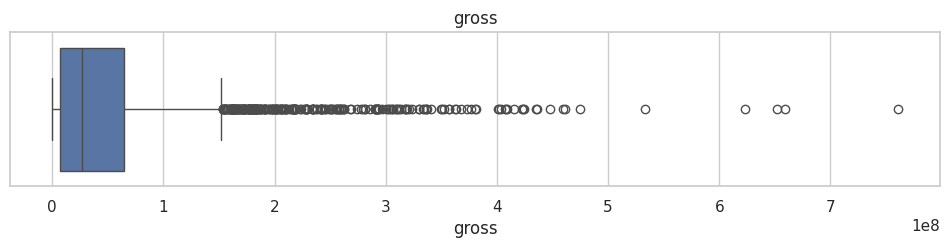

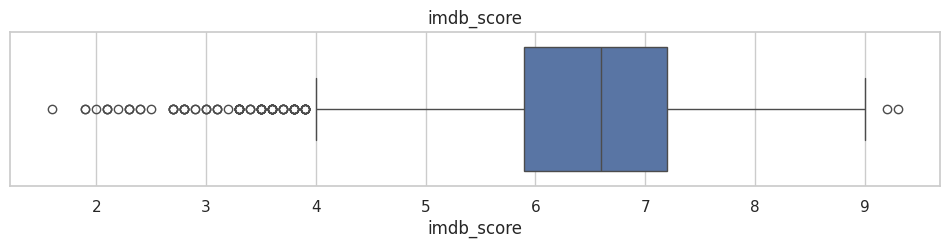

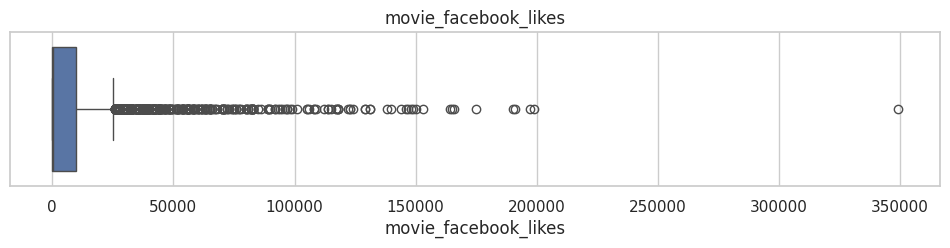

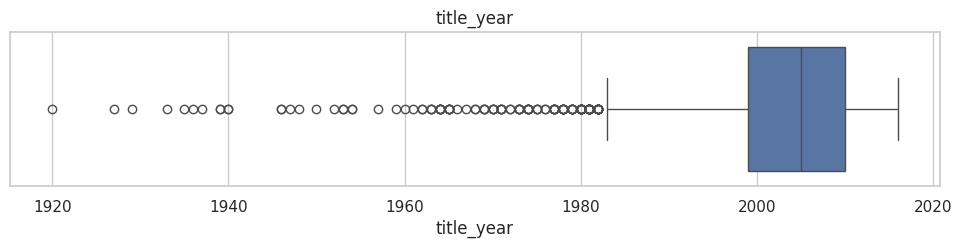

In [100]:
# visualize some numeric columns, look for any outliers
cols_to_plot = ['budget', 'gross', 'imdb_score', 'movie_facebook_likes', 'title_year']

for c in cols_to_plot:
    plt.figure(figsize=(12,2))
    sns.boxplot(x=df[c])
    plt.title(c)
    plt.show()

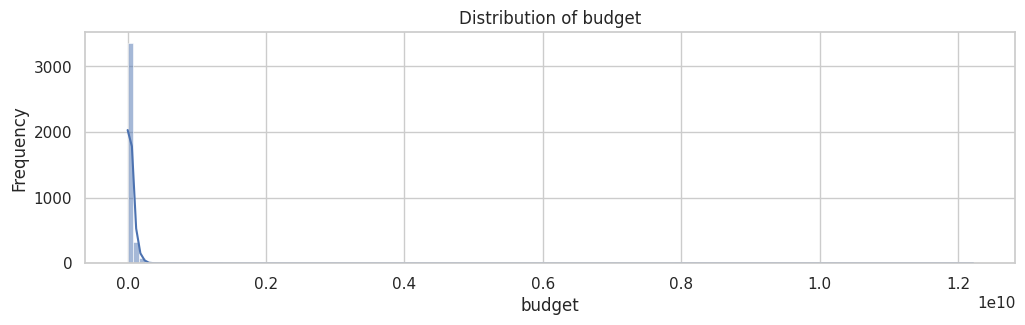

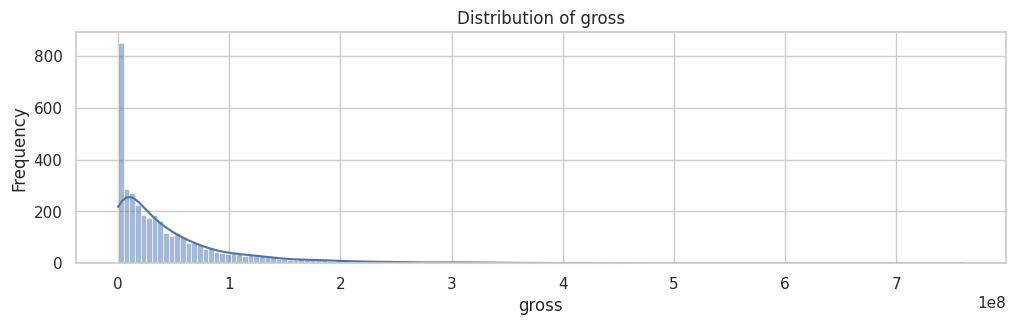

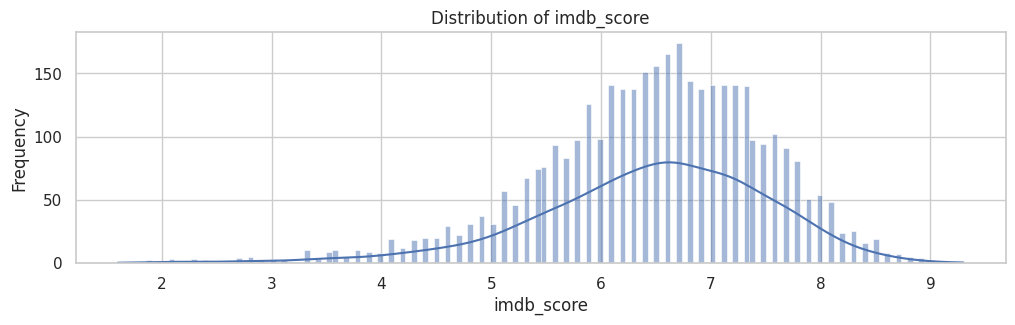

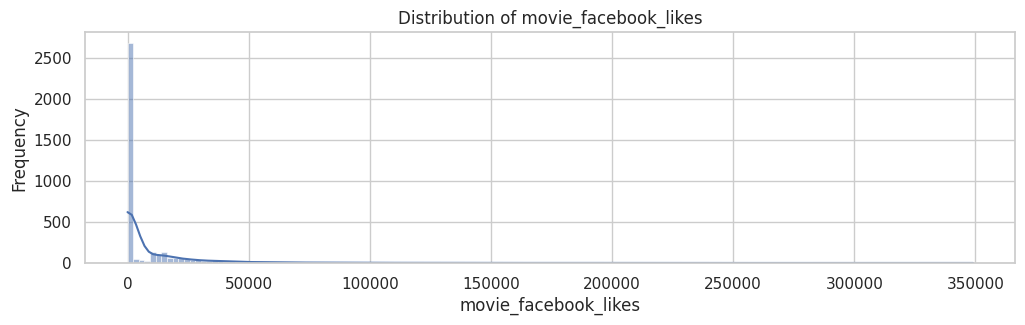

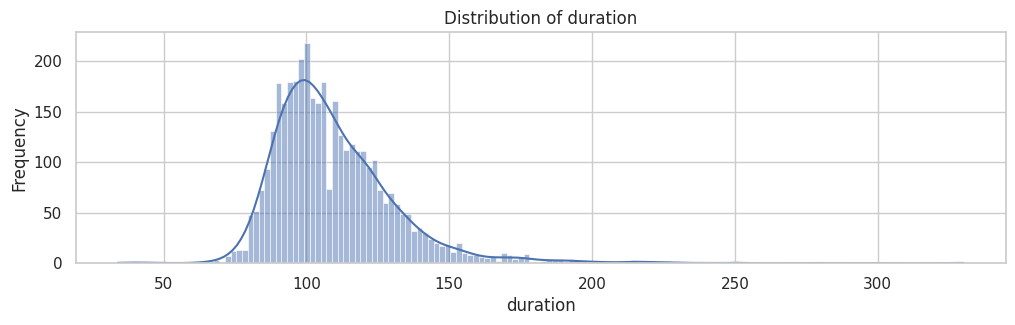

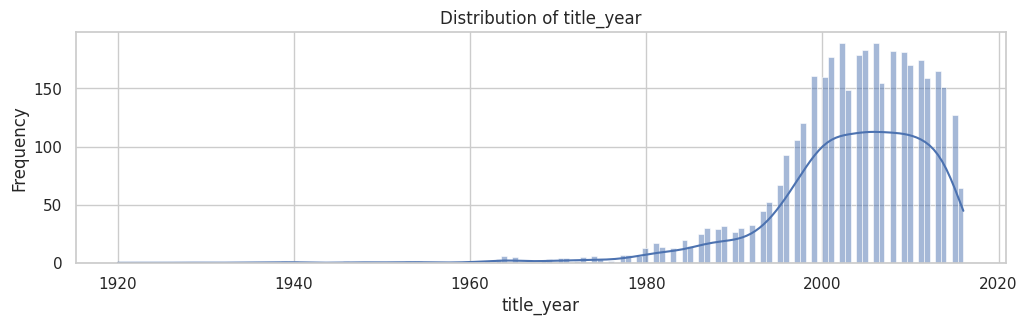

In [101]:
# Visualize distribution of numeric columns (histograms + KDE)
plot_cols = ['budget', 'gross', 'imdb_score', 'movie_facebook_likes', 'duration', 'title_year']

for col in plot_cols:
    plt.figure(figsize=(12,3))
    sns.histplot(df[col], kde=True, bins=150)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

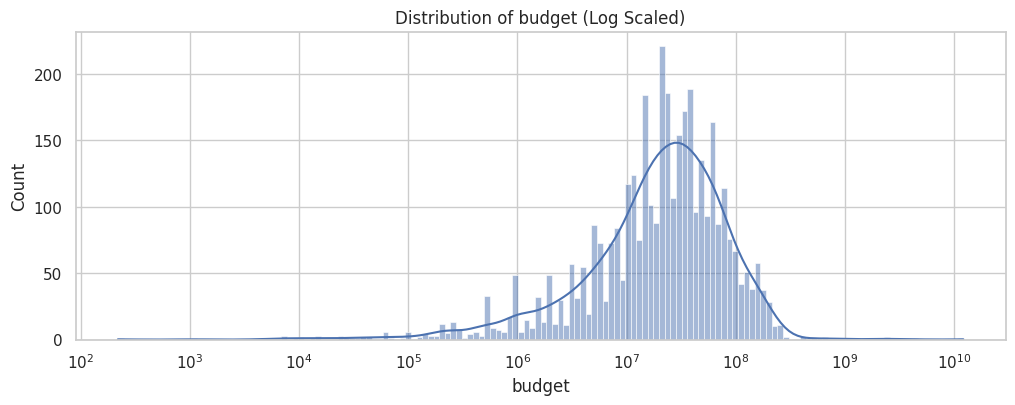

In [102]:
plt.figure(figsize=(12,4))
sns.histplot(df['budget'], kde=True, bins=150, log_scale=True)
plt.title("Distribution of budget (Log Scaled)")
plt.show()

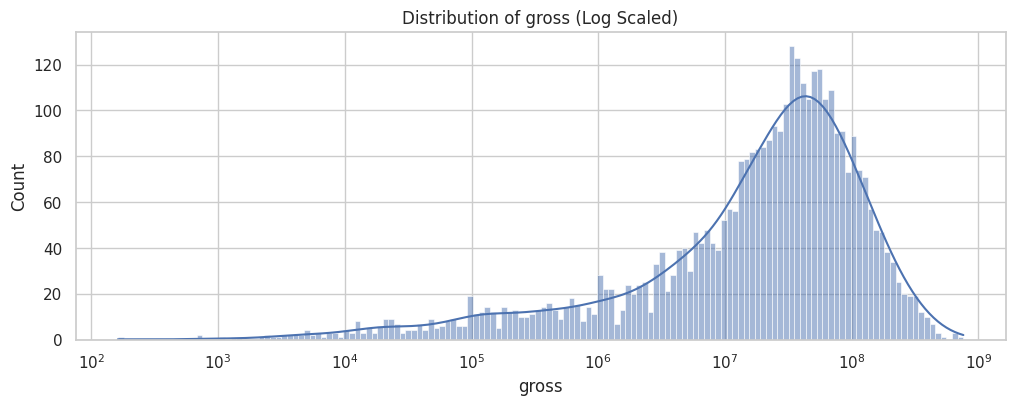

In [103]:
plt.figure(figsize=(12,4))
sns.histplot(df['gross'], kde=True, bins=150, log_scale=True)
plt.title("Distribution of gross (Log Scaled)")
plt.show()

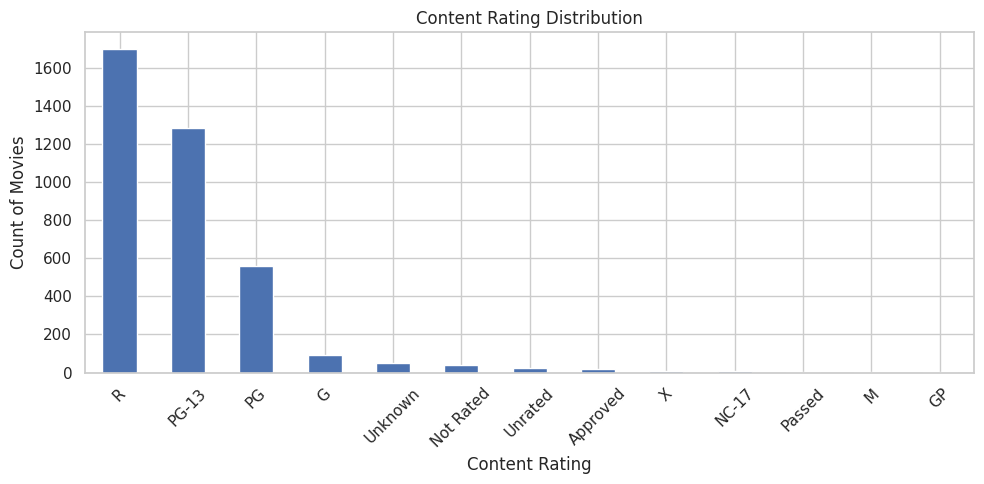

In [104]:
# Content Rating Distribution

plt.figure(figsize=(10,5))
df['content_rating'].value_counts().plot(kind='bar')

plt.title("Content Rating Distribution")
plt.xlabel("Content Rating")
plt.ylabel("Count of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

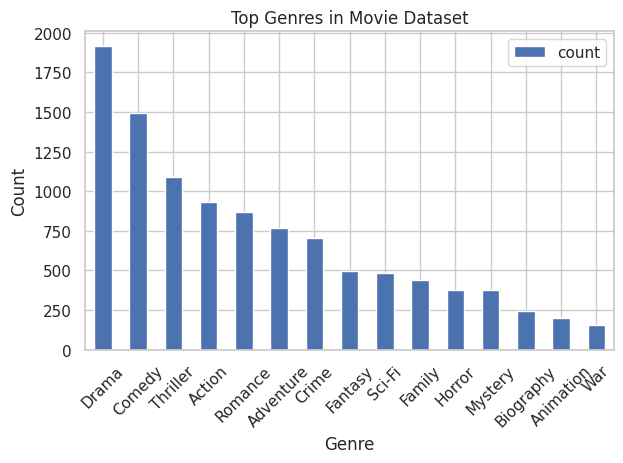

In [105]:
# Most Common Genres

from collections import Counter

# Drop missing values and split by "|"
genre_list = df['genres'].dropna().str.split('|').tolist()

# Flatten list
flat_genres = [g for sublist in genre_list for g in sublist]

# Count genre frequency
genre_counts = Counter(flat_genres)

# Convert to DataFrame for plotting
genre_df = pd.DataFrame.from_dict(genre_counts, orient='index', columns=['count'])
genre_df = genre_df.sort_values(by='count', ascending=False)

# Plot top 15 genres
plt.figure(figsize=(10,5))
genre_df.head(15).plot(kind='bar')

plt.title("Top Genres in Movie Dataset")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2.2 Bivariate Analysis - Compare two variables

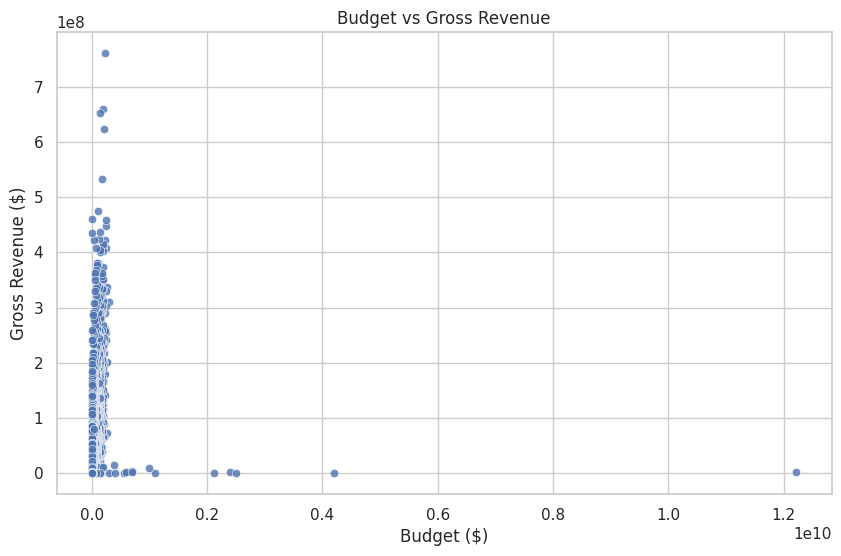

In [106]:
# Budget vs Gross Revenue

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='budget', y='gross', alpha=0.8)
plt.title('Budget vs Gross Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Gross Revenue ($)')
plt.show()

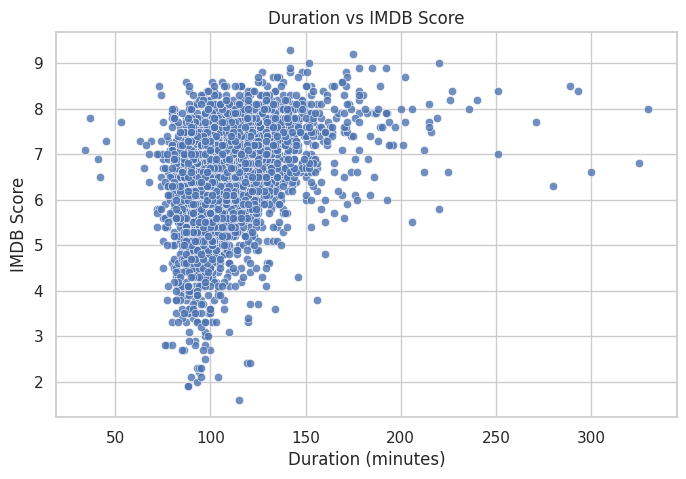

In [107]:
# Duration vs IMDB Score
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='duration', y='imdb_score', alpha=0.8)
plt.title("Duration vs IMDB Score")
plt.xlabel("Duration (minutes)")
plt.ylabel("IMDB Score")
plt.show()

<Figure size 1000x500 with 0 Axes>

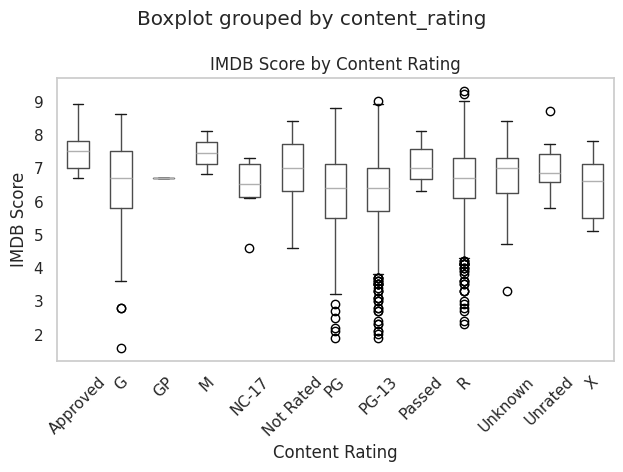

In [108]:
# Content Rating vs IMDB Score

plt.figure(figsize=(10,5))
df.boxplot(column="imdb_score", by="content_rating", grid=False, rot=45)
plt.title("IMDB Score by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("IMDB Score")
plt.tight_layout()
plt.show()

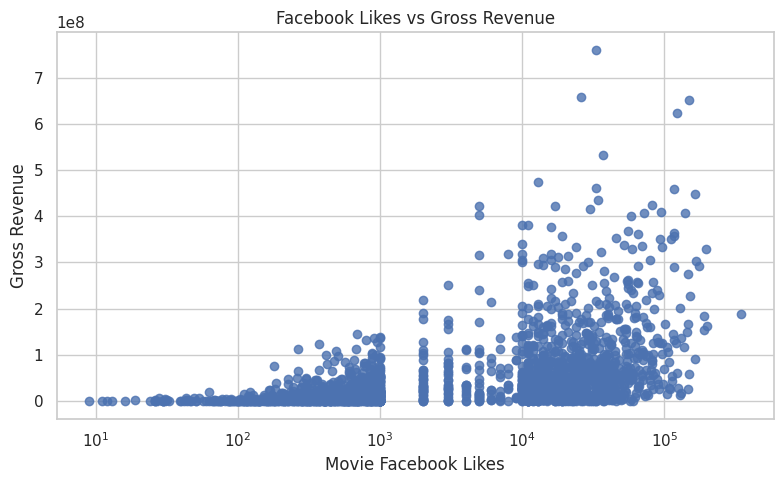

In [109]:
# Facebook Likes vs Gross Revenue
plt.figure(figsize=(8,5))
plt.scatter(df['movie_facebook_likes'], df['gross'], alpha=0.8)

plt.title("Facebook Likes vs Gross Revenue")
plt.xlabel("Movie Facebook Likes")
plt.ylabel("Gross Revenue")
plt.xscale('log')  # optional but helpful
plt.tight_layout()
plt.show()


### 2.3 Multivariate Analysis

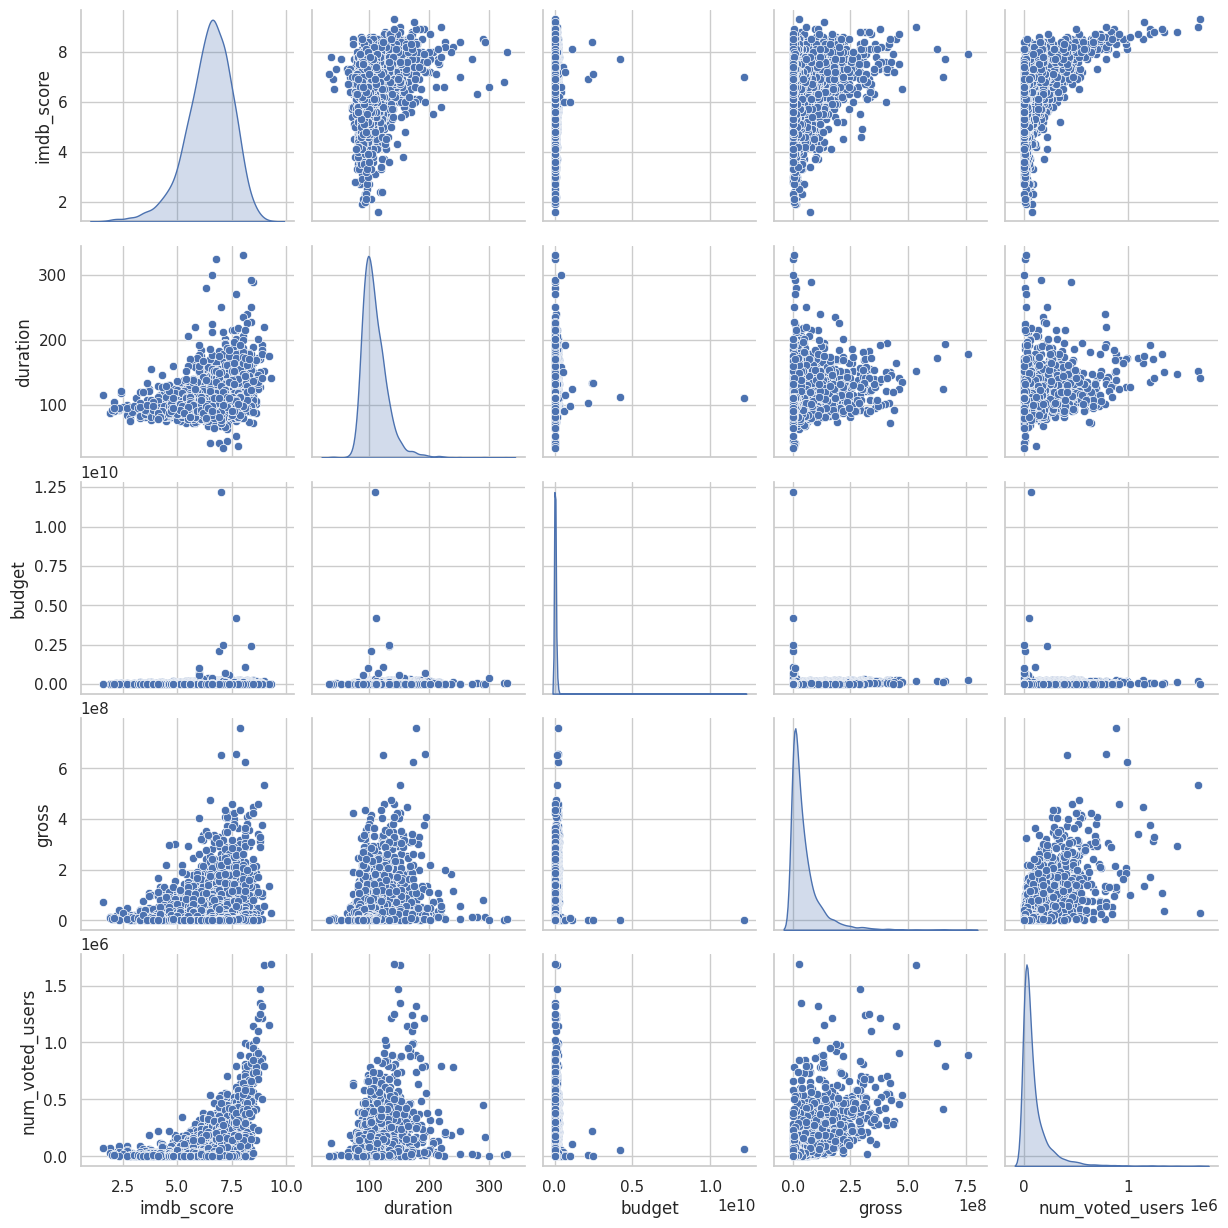

In [110]:
# Pairplot: quick visual overview of numeric relationships
sns.pairplot(df[['imdb_score', 'duration', 'budget', 'gross', 'num_voted_users']], diag_kind='kde')
plt.show()

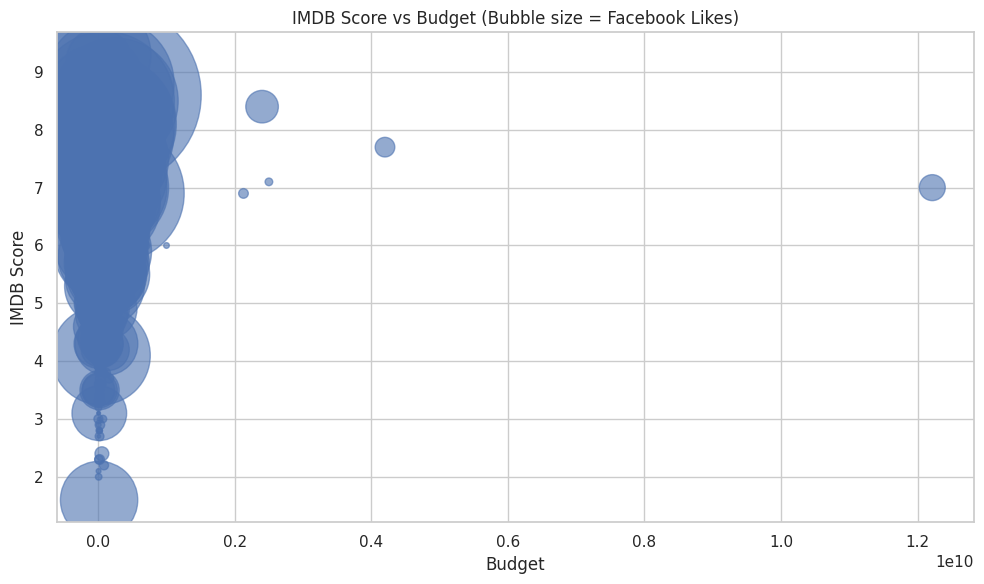

In [111]:
# IMDB Score vs Budget, Genre, and Facebook Likes
plt.figure(figsize=(10,6))
plt.scatter(
    df['budget'],
    df['imdb_score'],
    s=df['movie_facebook_likes'] / 20,   # size scaled
    alpha=0.6
)

plt.title("IMDB Score vs Budget (Bubble size = Facebook Likes)")
plt.xlabel("Budget")
plt.ylabel("IMDB Score")
plt.tight_layout()
plt.show()

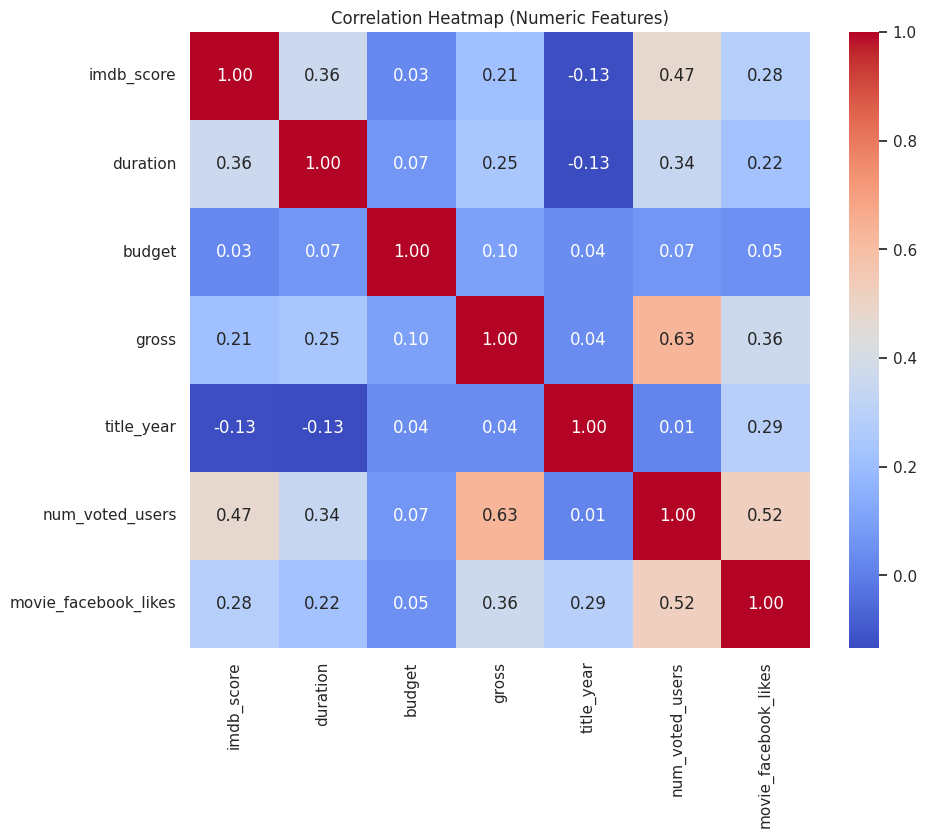

In [112]:
#Correlation between numeric columns
cor = df[['imdb_score', 'duration', 'budget', 'gross', 'title_year', 'num_voted_users', 'movie_facebook_likes']]

plt.figure(figsize=(10,8))
sns.heatmap(cor.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

<Figure size 1000x600 with 0 Axes>

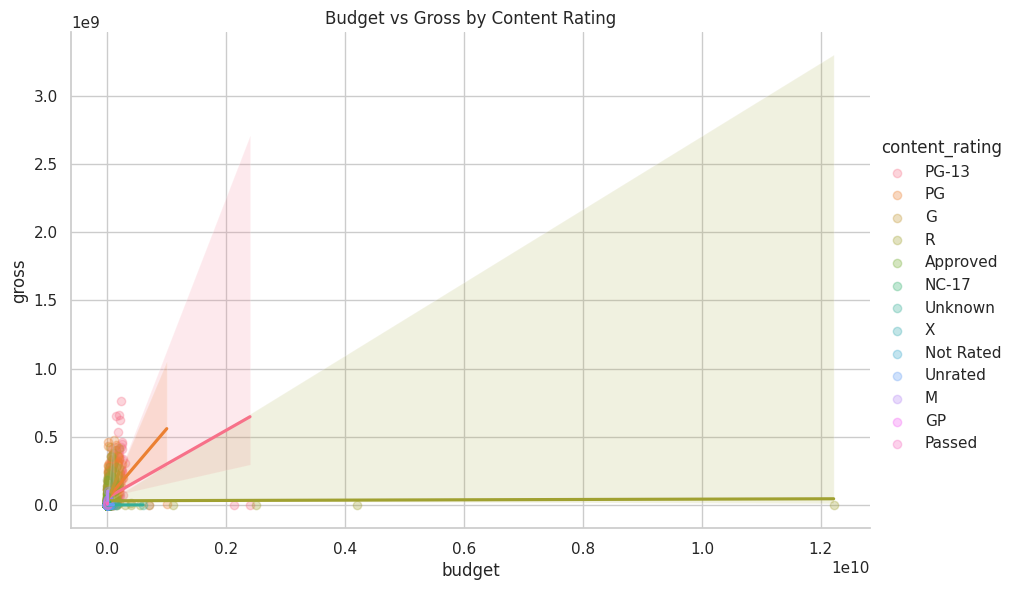

In [113]:
#Budget vs Gross (Regression by Content Rating)

plt.figure(figsize=(10,6))
sns.lmplot(
    data=df,
    x="budget",
    y="gross",
    hue="content_rating",
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.3}
)

plt.title("Budget vs Gross by Content Rating")
plt.show()

### 2.4 Temporal or Trend Analysis

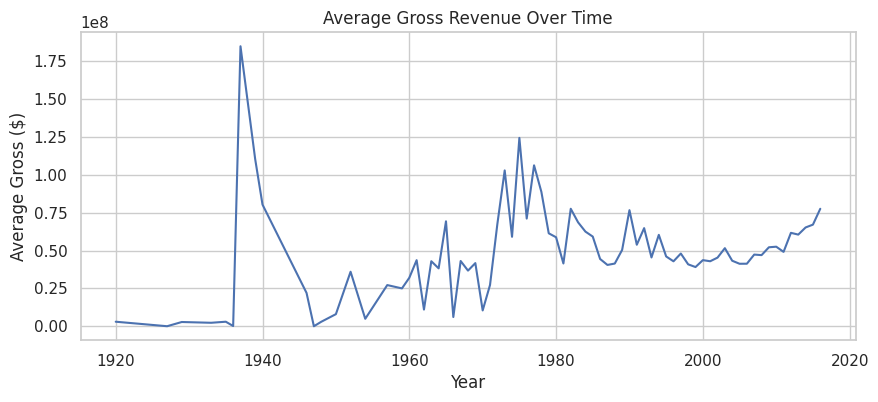

In [114]:
df.groupby('title_year')['gross'].mean().plot(kind='line', figsize=(10,4))
plt.title('Average Gross Revenue Over Time')
plt.xlabel('Year')
plt.ylabel('Average Gross ($)')
plt.show()

## 3. Business Insights (Top-N Ranking Analysis)

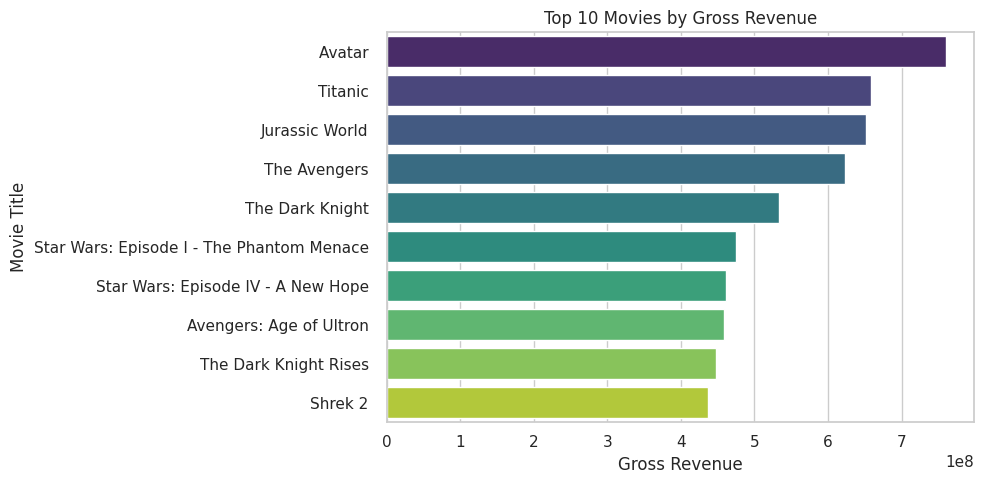

In [115]:
# Top 10 Movies by Gross
top10_movies = df[['movie_title', 'gross']].dropna().sort_values(by='gross', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='gross', y='movie_title', data=top10_movies, hue='movie_title', palette='viridis')
plt.title("Top 10 Movies by Gross Revenue")
plt.xlabel("Gross Revenue")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.show()

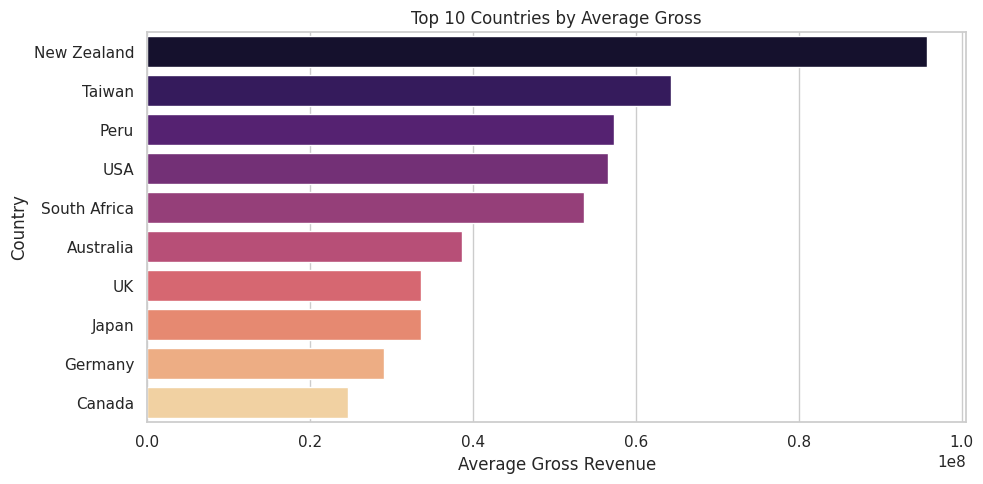

In [116]:
# Top 10 Countries by Average Gross
top10_countries = (
    df.groupby('country')['gross']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top10_countries.values, y=top10_countries.index, hue=top10_countries.index, palette='magma')
plt.title("Top 10 Countries by Average Gross")
plt.xlabel("Average Gross Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


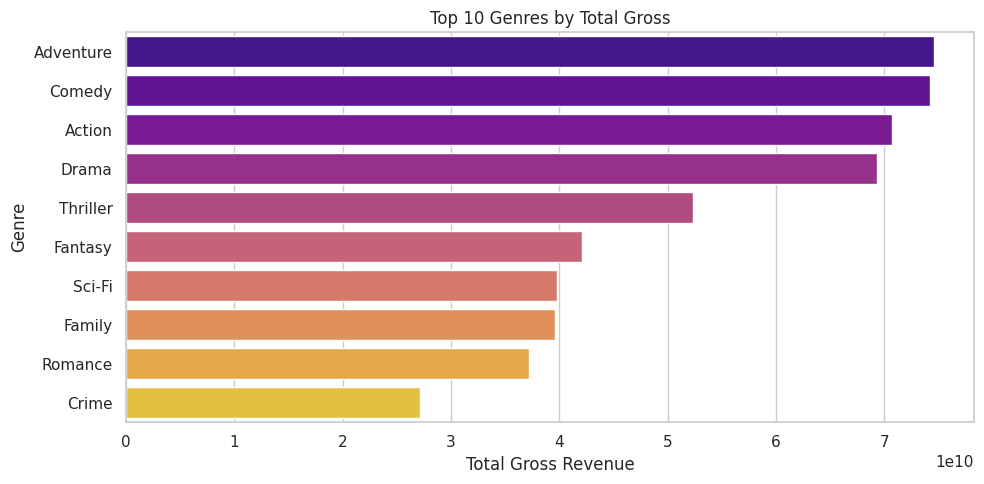

In [117]:
from collections import defaultdict

genre_gross = defaultdict(int)

for _, row in df[['genres', 'gross']].dropna().iterrows():
    genre_list = row['genres'].split('|')
    for g in genre_list:
        genre_gross[g] += row['gross']

genre_gross_df = pd.DataFrame.from_dict(genre_gross, orient='index', columns=['gross'])
top10_genres = genre_gross_df.sort_values(by='gross', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10_genres['gross'], y=top10_genres.index, hue=top10_genres.index, palette='plasma')
plt.title("Top 10 Genres by Total Gross")
plt.xlabel("Total Gross Revenue")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


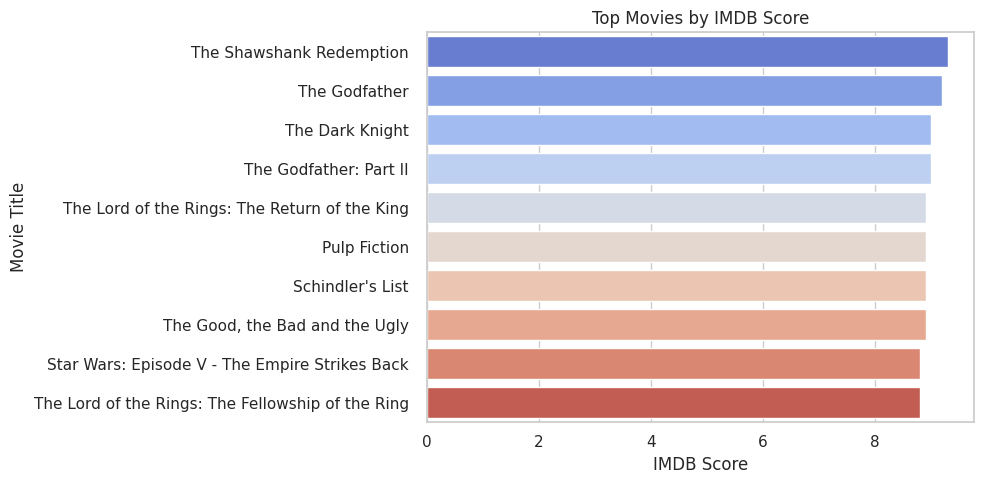

In [118]:
# Top Movies by IMDB Score
top_imdb = df[['movie_title', 'imdb_score']].dropna().sort_values(by='imdb_score', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='imdb_score', y='movie_title', data=top_imdb, hue='movie_title', palette='coolwarm')
plt.title("Top Movies by IMDB Score")
plt.xlabel("IMDB Score")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.show()

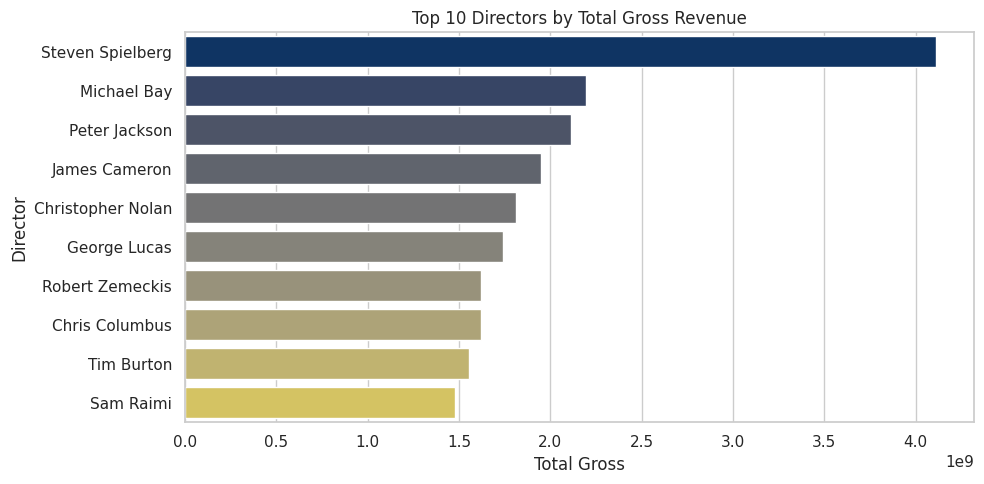

In [119]:
# Top Directors by Total Gross
top_directors_gross = (
    df.groupby('director_name')['gross']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors_gross.values, y=top_directors_gross.index, hue=top_directors_gross.index, palette='cividis')
plt.title("Top 10 Directors by Total Gross Revenue")
plt.xlabel("Total Gross")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

## **Conclusion**

This project provided a structured exploration of the movie metadata dataset using **Python-driven data analysis and visualization techniques**. By walking through univariate, bivariate, and multivariate analysis, I gained a clearer understanding of how key variables behave—ranging from basic distributions to deeper relationships between ratings, budgets, popularity, and genre patterns. The results showed how factors like **production budget**, **genre**, and **audience engagement** (including social media metrics) connect to both viewer ratings and box-office performance.

In addition, **Top-N rankings** helped highlight high-performing movies, leading production countries, and the genres that consistently resonate with audiences. Overall, this project demonstrates how thoughtful data exploration can transform raw movie data into practical insights, offering a strong foundation for further modeling, forecasting, or decision-making.